In [40]:
import pandas as pd
from IPython.display import Markdown, display
import seaborn as sns
import matplotlib.pyplot as plt

# **1. Data collection / loading**

In [41]:
def load_excel_file(sheet_name):
  LOCAL_EXCEL_FILE_PATH = "../data/raw/covid_19_dataset.xlsx"
  REMOTE_EXCEL_FILE_PATH = "https://raw.githubusercontent.com/chetanchandel31/da-covid19/main/data/raw/covid_19_dataset.xlsx"
  try:
    return pd.read_excel(LOCAL_EXCEL_FILE_PATH, sheet_name=sheet_name)
  except FileNotFoundError:
    return pd.read_excel(REMOTE_EXCEL_FILE_PATH, sheet_name=sheet_name, engine="openpyxl")
  except Exception as e:
    print("unexpected error while loading data", e)
    raise

df_deaths = load_excel_file("covid_19_deaths_v1")
df_confirmed = load_excel_file("covid_19_confirmed_v1")
df_recovered = load_excel_file("covid_19_recovered_v1")

# **2. Data inspection / exploration**

In [42]:
for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
    display(Markdown(f"## **{name}**"))
    display(Markdown(f"**Shape:** {df.shape}"))

    # ~494 columns, too much noise in output
    # print("Columns:", end=" ")
    # print(*df.columns, sep=", ")

    non_date_cols = ["Province/State", "Country/Region", "Lat", "Long"]
    date_cols = [c for c in df.columns if c not in non_date_cols]
    display(Markdown(f"**Non date columns**: {len(non_date_cols)} ({', '.join(non_date_cols)})"))
    display(Markdown(f"**Date columns:** {len(date_cols)} (from {date_cols[0]} to {date_cols[-1]})"))
    display(Markdown(f"*Subset of date column headers*: {date_cols[0:15]}"))

    df_dtypes = df.dtypes
    display(Markdown("**Column wise data types**:"))
    display(df_dtypes)

    date_col_dtypes = set()
    for idx, val in df_dtypes.items():
        if idx not in non_date_cols:
            date_col_dtypes.add(val)

    display(Markdown(f"**Unique data types for date-columns' values:** {list(date_col_dtypes)}"))
    display(Markdown(f"**Highest date:** {max(pd.to_datetime(date_cols, errors='coerce', format='mixed', dayfirst=False))}"))

    display(Markdown(f"**Null values in column headers**(includes potential null dates): {df.columns.isna().sum()}"))
    display(Markdown(f"**Null values across entire dataset**: {df.isna().sum().sum()}"))
    print()
    display(Markdown("---"))

## **Deaths**

**Shape:** (276, 498)

**Non date columns**: 4 (Province/State, Country/Region, Lat, Long)

**Date columns:** 494 (from 1/22/20 to 5/29/21)

*Subset of date column headers*: ['1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', datetime.datetime(2020, 1, 2, 0, 0), datetime.datetime(2020, 2, 2, 0, 0), datetime.datetime(2020, 3, 2, 0, 0), datetime.datetime(2020, 4, 2, 0, 0), datetime.datetime(2020, 5, 2, 0, 0)]

...

**Unique data types for date-columns' values:** [dtype('int64'), dtype('float64')]

**Highest date:** 2021-12-05 00:00:00

**Null values in column headers**(includes potential null dates): 0

**Null values across entire dataset**: 194

---

### Structure of raw dataset

- **Shape of data:** Each sheet has 498 columns, suggesting cases recorded over same dates in each sheet. However, the sheet with recovered cases has fewer rows(261) than the other 2 sheets(containing 276 rows each), suggesting recovered cases recorded over comparatively fewer locations.

- **Datatypes of non-date column values:** Location related columns(`Province/State`, `Country/Region`) are correctly typed as `str` and the coordinates(`Lat` and `Long` columns) are `float64`.

- **Datatypes under date-column values:** Values present in date-columns under "confirmed cases" are correctly typed as `int64` confirming zero `NaN` values there. In the other 2 sheets, individual date-columns are typed as either `int64` or `float64`, some columns are one, some are the other, indicating `NaN`s are present in at least some of those columns (`NaN` forces a column to upcast to `float64`), since "number of cases" generally can't be a decimal number.

- **Discrepancy in column header datatype:** 
  - Date *column headers*, however, are inconsistently typed - a mix of `str` (e.g. `'1/22/20'`) and `datetime.datetime` objects (e.g. `datetime(2020, 1, 2)`), likely due to inconsistent cell formatting in the original Excel file.
  - As a result, in "subset of date column headers", after dates from January, we see dates like `['2020-01-02 00:00:00', '2020-02-02 00:00:00', '2020-03-02 00:00:00', '2020-04-02 00:00:00']` which reads as `2 Jan 2020, 2 Feb 2020, 2 March 2020...` instead of `1 Feb 2020, 2 Feb 2020, 3 Feb 2020...` as the automatic conversion is swapping month and date because of inconsistent date string format.
  
    Another observation is `2021-12-05 00:00:00`(5 Dec 2021) being read as the `highest date` while from our raw inspection of columns, the dates seem to be chronologically ordered, in case this assumption holds, the last date among column headers, which should also be the `highest date` is `5/29/21`(29 May 2021).
  - This will need to be normalized to a single consistent type before melting
  to long format for time-series analysis.

- **Null values:**
  - **Column headers:** The column headers contain 0 null values which is important to know because it tells us we don't have to worry about imputing missing values before normalizing dates(as those are a subset of column headers in this dataset).
  - **Dataset:** Although, the entire dataset itself does contain 195 null values in "deaths" dataset and 194 null values in "confirmed" and "recovered" each, which will have to be dealt with moving forward.

# **3. Data cleaning**

### 3.1 Normalize inconsistent dates

In [43]:
# re-run this cell using "run-all", never in isolation because then it'll read the reassigned `df` and before-after comparison will be meaningless
def convert_date_string(date_string):
  date_string = str(date_string)
  if date_string[-3] == "/":
    return date_string

  date_part = date_string.split(" ")[0]
  year_part, month_part, day_part = date_part.split("-")

  # swap month and day
  month_part, day_part = day_part, month_part

  # strip 0s and trim year
  if month_part[0] == "0":
    month_part = month_part[-1]
  if day_part[0] == "0":
    day_part = day_part[-1]
  year_part = year_part[2:]
  
  return "/".join([month_part, day_part, year_part])

for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
  display(Markdown(f"## **{name}**"))

  display(Markdown("### **Before conversion:**"))

  non_date_cols = ["Province/State", "Country/Region", "Lat", "Long"]
  date_cols = [c for c in df.columns if c not in non_date_cols]

  display(Markdown(f"**Subset of date column headers**: {df.columns.to_list()[0:20]}"))
  max_date = max(pd.to_datetime(date_cols, format='mixed', dayfirst=False))
  last_date = pd.to_datetime(df.columns[-1])
  display(Markdown(f"**Max date:** {max_date}, **Last date:** {last_date}, **Max date = Last date:** {max_date == last_date}"))

  display(Markdown("### **After conversion:**"))

  df.columns = pd.concat([
    pd.Series(non_date_cols),
    pd.to_datetime(pd.Series(date_cols).apply(convert_date_string), format="mixed")
  ])  
  
  updated_date_cols = [c for c in df.columns if c not in non_date_cols]
  display(Markdown(f"**Subset of date column headers**: {df.columns.to_list()[0:20]}"))
  max_date = max(updated_date_cols)
  last_date = df.columns[-1]
  display(Markdown(f"**Max date:** {max_date}, **Last date:** {last_date}, **Max date = Last date:** {max_date == last_date}"))
  display(Markdown("---"))

## **Deaths**

### **Before conversion:**

**Subset of date column headers**: ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', datetime.datetime(2020, 1, 2, 0, 0), datetime.datetime(2020, 2, 2, 0, 0), datetime.datetime(2020, 3, 2, 0, 0), datetime.datetime(2020, 4, 2, 0, 0), datetime.datetime(2020, 5, 2, 0, 0), datetime.datetime(2020, 6, 2, 0, 0)]

**Max date:** 2021-12-05 00:00:00, **Last date:** 2021-05-29 00:00:00, **Max date = Last date:** False

### **After conversion:**

...

**Max date:** 2021-12-05 00:00:00, **Last date:** 2021-05-29 00:00:00, **Max date = Last date:** False

### **After conversion:**

**Subset of date column headers**: ['Province/State', 'Country/Region', 'Lat', 'Long', Timestamp('2020-01-22 00:00:00'), Timestamp('2020-01-23 00:00:00'), Timestamp('2020-01-24 00:00:00'), Timestamp('2020-01-25 00:00:00'), Timestamp('2020-01-26 00:00:00'), Timestamp('2020-01-27 00:00:00'), Timestamp('2020-01-28 00:00:00'), Timestamp('2020-01-29 00:00:00'), Timestamp('2020-01-30 00:00:00'), Timestamp('2020-01-31 00:00:00'), Timestamp('2020-02-01 00:00:00'), Timestamp('2020-02-02 00:00:00'), Timestamp('2020-02-03 00:00:00'), Timestamp('2020-02-04 00:00:00'), Timestamp('2020-02-05 00:00:00'), Timestamp('2020-02-06 00:00:00')]

**Max date:** 2021-05-29 00:00:00, **Last date:** 2021-05-29 00:00:00, **Max date = Last date:** True

---

#### Validation

As a validation check, comparing **"max date column header"** against the **"last column header"** confirms our fix, this equality held `False` on the raw data (`2021-12-05` was incorrectly computed as the max due to the day/month swap) and now holds `True` after normalization.

### 3.2 Handling/imputing missing data

In [44]:
for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
  display(Markdown(f"### **{name}**"))
  display(Markdown(f"**Total null values:** {df.isna().sum().sum()}"))

  display(Markdown(f"**Column-wise breakdown of null values:**"))
  df_col_null_values = df.isna().sum()
  display(df_col_null_values[df_col_null_values > 0])

### **Deaths**

**Total null values:** 195

**Column-wise breakdown of null values:**

Province/State         190
Lat                      2
Long                     2
2020-04-20 00:00:00      1
dtype: int64

### **Confirmed**

...

Province/State    190
Lat                 2
Long                2
dtype: int64

### **Recovered**

**Total null values:** 194

**Column-wise breakdown of null values:**

Province/State         191
Lat                      1
Long                     1
2020-04-20 00:00:00      1
dtype: int64

- Since we had already established there's no null value in "column headers", there was no need to check or impute anything there.
- From the distribution of null values, we can tell it needs to be handled in 3 parts
  - Province/State column - This column contains the majority of the null values.
  - Lat and long columns - These 2 columns will be handled together because they both represent the same issue i.e. missing geographical coordinates.
  - One date column - Date column for `2020-04-20 00:00:00` has 1 null value in "Deaths" and "Confirmed" datasets.

#### 3.2.1 understanding null values in `Province/State` column 

In [45]:
for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
  display(Markdown(f"## **{name}**"))
  display(Markdown(f"**Total null Province rows:** {df['Province/State'].isna().sum()}"))
  print()
  df_country_to_null_province_count = df[df['Province/State'].isna()]['Country/Region'].value_counts()
  display(Markdown(f"**Countries having more than 1 null Province rows:** {df_country_to_null_province_count[df_country_to_null_province_count > 1].sum()}"))
  display(Markdown(f"**Countries having exactly 1 null Province row:** {df_country_to_null_province_count[df_country_to_null_province_count == 1].sum()}"))
  print()

  def summarize_provinces(x):
    province_count = x.shape[0]
    null_province_count = x["Province/State"].isna().sum()
    return pd.Series({"province_count": province_count, "null_province_count": null_province_count})
  df_countrywise_province_summary = df.groupby("Country/Region").apply(summarize_provinces, include_groups=False)

  has_one_null = df_countrywise_province_summary["null_province_count"] == 1
  has_one_total = df_countrywise_province_summary["province_count"] == 1
  has_many_total = df_countrywise_province_summary["province_count"] > 1

  display(Markdown(f"**Countries having 1 Province row, which is also `null`:** {df_countrywise_province_summary[has_one_null & has_one_total].shape[0]}"))  
  display(Markdown(f"**Countries having multiple Province rows, which *includes* a `null` Province:** {df_countrywise_province_summary[has_one_null & has_many_total].shape[0]}"))
  print()
  display(Markdown("---"))

## **Deaths**

**Total null Province rows:** 190

**Countries having more than 1 null Province rows:** 0

**Countries having exactly 1 null Province row:** 190

**Countries having 1 Province row, which is also `null`:** 186

...

**Countries having more than 1 null Province rows:** 0

**Countries having exactly 1 null Province row:** 191

**Countries having 1 Province row, which is also `null`:** 187

**Countries having multiple Province rows, which *includes* a `null` Province:** 4

---

#### Data imputation strategy
- Since there are 0 **"Countries having more than 1 null Province rows"** and **"Countries having exactly 1 null Province row"** exactly equals **"Total null Province rows"**, we can rule out the possibility of a country having multiple "unknown Province" columns. 

- Instead, we see sum of **"Countries having 1 Province row, which is also null"** and **"Countries having multiple Province rows, which includes a null Province"** also exactly equals **"Total null Province rows"**, so the null provinces are actually divided into these 2 categories:
  - **Countries having one null Province row which is also its only Province:** Here we will impute the missing values with "All Provinces" since these countries have no province-level breakdown at all (single row = entire country).
  - **Countries having multiple named Province rows including a null Province:** Here, using "All Provinces" to impute missing values will be inaccurate as these Countries clearly have rows to represent their other Provinces, so we'll use "Unknown Province(s)" to missing null Provinces of this category. 

In [46]:

for name, df in [("Deaths", df_deaths), ("Confirmed", df_confirmed), ("Recovered", df_recovered)]:
  display(Markdown(f"## **{name}**"))

  df_country_to_province_count = df.groupby("Country/Region").agg(province_count=("Province/State", "size")).reset_index()
  single_province_country_count = df_country_to_province_count[df_country_to_province_count["province_count"] == 1].shape[0]
  multiple_province_country_count = df_country_to_province_count[df_country_to_province_count["province_count"] > 1].shape[0]

  display(Markdown(f"**Countries with more than 1 province rows:** {multiple_province_country_count} <br/> **Countries with exactly 1 province row:** {single_province_country_count}"))

  countries_with_multiple_province_rows = df_country_to_province_count[df_country_to_province_count["province_count"] > 1]["Country/Region"]

  province_is_null = df["Province/State"].isna()
  country_has_multiple_province_rows = df["Country/Region"].isin(countries_with_multiple_province_rows)

  df.loc[province_is_null & country_has_multiple_province_rows, 'Province/State'] = "Unknown Province(s)"
  df.loc[province_is_null & (~country_has_multiple_province_rows), "Province/State"] = "All Provinces"

  display(Markdown(f"**Null provinces after imputation:** {df['Province/State'].isna().sum()}"))

## **Deaths**

**Countries with more than 1 province rows:** 7 <br/> **Countries with exactly 1 province row:** 186

**Null provinces after imputation:** 0

## **Confirmed**

**Countries with more than 1 province rows:** 7 <br/> **Countries with exactly 1 province row:** 186

**Null provinces after imputation:** 0

## **Recovered**

**Countries with more than 1 province rows:** 6 <br/> **Countries with exactly 1 province row:** 187

**Null provinces after imputation:** 0

#### Summary

Since the number of countries with more than 1 province rows is much smaller(i.e. 7) than the ones with only one province row(i.e. 186), we used a list of such countries to determine whether a `null` province belong to a **"Country with many province rows"** and needs to be imputed with "Unknown Province(s)" or the null province belongs to a **"Country with only one province row"** and needs to be imputed with "All Province(s)".

**Null values in china's date columns:** 0

**Null values in china's date columns headers:** 0

,Dates,58,59,60,61,62,63,64,65,66,...,83,84,85,86,87,88,89,90,91,total cases
0,2020-01-22,1,14,6,1,0,26,2,1,4,...,9,1,5,4,0,0,0,1,10,548
1,2020-01-23,9,22,9,5,2,32,5,3,5,...,16,1,8,4,0,0,2,2,27,643
2,2020-01-24,15,36,27,10,2,53,23,3,8,...,20,1,15,8,0,0,2,5,43,920
3,2020-01-25,39,41,57,18,4,78,23,4,19,...,33,6,28,10,0,0,3,11,62,1406
4,2020-01-26,60,68,75,35,7,111,36,5,22,...,40,9,44,14,0,0,4,16,104,2075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,2021-05-25,1004,1058,598,616,194,2413,275,147,188,...,2078,253,1018,393,1,0,980,352,1363,102905
490,2021-05-26,1004,1059,598,617,194,2427,275,147,188,...,2079,253,1019,393,1,0,980,352,1363,102925
491,2021-05-27,1004,1059,598,617,194,2428,275,147,188,...,2081,253,1022,393,1,0,980,352,1363,102932
492,2021-05-28,1004,1059,598,618,194,2431,275,147,188,...,2088,253,1024,393,1,0,980,352,1364,102948


'2021-05-29'

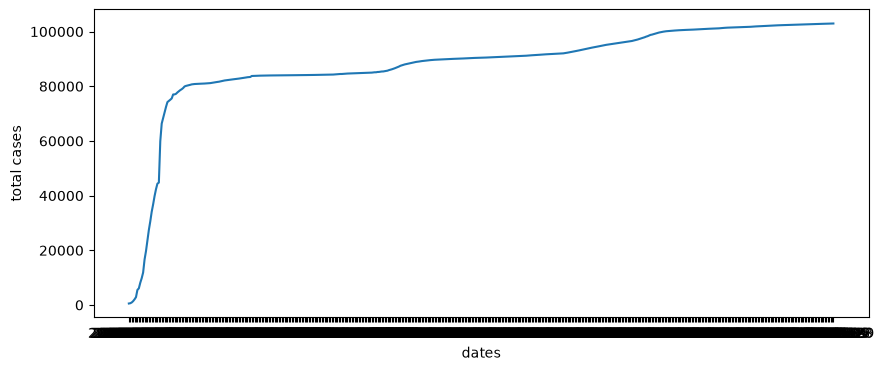

In [47]:
df_china_confirmed_cases = df_confirmed[df_confirmed["Country/Region"] == "China"].copy()

df_china_confirmed_date_cols = df_china_confirmed_cases.iloc[:,4:]

display(Markdown(f"**Null values in china's date columns:** {df_china_confirmed_date_cols.isna().sum().sum()}"))
display(Markdown(f"**Null values in china's date columns headers:** {df_china_confirmed_date_cols.columns.isna().sum()}"))
df_china_confirmed_date_cols = df_china_confirmed_date_cols.T
df_china_confirmed_date_cols["total cases"] = df_china_confirmed_date_cols.sum(axis=1)
df_china_confirmed_date_cols.reset_index(inplace=True, names="Dates")
# df_china_confirmed_date_cols["Dates"] = pd.to_datetime(df_china_confirmed_date_cols["Dates"].astype(str).str.replace("/", "-"), format="mixed", dayfirst=False) 
# df_china_confirmed_date_cols.index = pd.to_datetime(df_china_confirmed_date_cols.index, format="mixed", dayfirst=False)

# normalize all date-strings to a uniform dd-mm-yyyy format, then convert to datetime
df_china_confirmed_date_cols["Dates"] = df_china_confirmed_date_cols["Dates"].astype(str).apply(lambda x: x)

display(df_china_confirmed_date_cols)
display(df_china_confirmed_date_cols["Dates"].max())

plt.figure(figsize=(10,4))
sns.lineplot(data=df_china_confirmed_date_cols, x="Dates", y="total cases")
plt.xlabel("dates")
plt.show()

# 05-12-2021

# df_china_confirmed_date_cols["Dates"].max()